<a href="https://colab.research.google.com/github/SiddhantUke/LangGraph/blob/main/Nvidia_NIM_TESTING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U langchain-nvidia-ai-endpoints langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 6.6 MB/s eta 0:00:00


In [4]:
import os
from google.colab import userdata

os.environ["NVIDIA_API_KEY"] = userdata.get("NVIDIA_API_KEY")

print("Key loaded:", bool(os.getenv("NVIDIA_API_KEY")))
print("API key length:", len(os.getenv("NVIDIA_API_KEY", "")))

Key loaded: True
API key length: 70


In [16]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA

llm = ChatNVIDIA(
    model="nvidia/nemotron-3-ultra-550b-a55b",
    api_key=os.getenv("NVIDIA_API_KEY"),
    temperature=0.7
)

In [7]:
import os

from typing import TypedDict

from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langgraph.graph import StateGraph, START, END

In [10]:
# -------------------------
# 2. Define State
# -------------------------

class State(TypedDict):
    question: str
    answer: str



In [11]:

# -------------------------
# 3. Define Node
# -------------------------

def chatbot(state: State):

    response = llm.invoke(
        state["question"]
    )

    return {
        "answer": response.content
    }



In [12]:

# -------------------------
# 4. Build Graph
# -------------------------

graph_builder = StateGraph(State)

graph_builder.add_node(
    "chatbot",
    chatbot
)

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_edge(
    "chatbot",
    END
)




In [18]:
# -------------------------
# 5. Compile
# -------------------------

graph = graph_builder.compile()



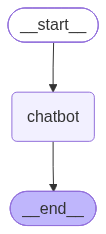

In [19]:
graph

In [14]:
result = graph.invoke({
    "question": "Hello",
    "answer": ""
})

print(result["answer"])

Hello! How can I help you today?


In [17]:

# -------------------------
# 6. Invoke
# -------------------------

result = graph.invoke({
    "question": "What is a vector database?",
    "answer": ""
})

print(result["answer"])

A **vector database** is a specialized database designed to store, index, and query **high-dimensional vectors** (arrays of numbers) efficiently.

Unlike traditional databases that look for **exact matches** (e.g., `WHERE name = "John"`), vector databases are built for **similarity search** (e.g., "Find the 10 items most *similar* to this one").

---

### 1. The Core Concept: Vectors (Embeddings)
Modern AI models (LLMs, image models, audio models) convert unstructured data (text, images, audio, video) into **lists of floating-point numbers** called **vectors** or **embeddings**.

*   **Text:** "The cat sat on the mat" $\rightarrow$ `[0.12, -0.45, 0.88, ..., 0.03]` (e.g., 1,536 dimensions)
*   **Image:** `cat_photo.jpg` $\rightarrow$ `[0.91, 0.02, -0.33, ..., 0.55]` (e.g., 512 dimensions)

**The Magic:** In this vector space, **semantic meaning equals geometric proximity**.
*   Vectors for "King" and "Queen" are close together.
*   Vectors for "Apple" (fruit) and "Banana" are close.
*  